LING 380

Assignment 2

April 11, 2025



In [1]:
import os
import random
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk import classify
from nltk.classify import DecisionTreeClassifier
from nltk.classify import NaiveBayesClassifier
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import string
from nltk.tokenize import word_tokenize
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from collections import defaultdict
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [3]:

nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\robca\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\robca\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\robca\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\robca\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [7]:
# Sentiment Analysis

def get_sentiment_scores(text):
    """
    Uses VADER within NLTK to calculate sentiment

    Args:
        text (str): a string containing the file or text

    Returns:
        dict: a dictionary that VADER creates
    """
    analyzer = SentimentIntensityAnalyzer()
    score = analyzer.polarity_scores(text)
    return score

def preprocess_text(text):
    """
    Tokenizes, makes all words lower case, removes stopwords and punctuation, and stems words

    Args:
        text (str): a string containing the file or text

    Returns:
        words: a list of the processed words
    """
    words = word_tokenize(text)
    words = [word.lower() for word in words if word.lower() not in stop_words and word not in string.punctuation]
    words = [stemmer.stem(word) for word in words]
    return words

def read_files_from_folder(folder_path, label):
    """
    Read all words from text files in folder

    Args:
        folder_path: the path for the folder
        label: the positive or negative label to be applied to each word

    Returns:
        labeled_data: a list of the (word,label) pairs
    """
    file_names = os.listdir(folder_path)
    labeled_data = []

    for file_name in file_names:
        file_path = os.path.join(folder_path, file_name)
        if file_path.endswith('.txt'):
            with open(file_path, 'r', encoding='utf-8') as file:
                words = file.read().splitlines()
                labeled_data.extend([(word, label) for word in words])

    return labeled_data


def process_dir(path):
    """
    Reads all the files in a directory. Processes them using the 'get_sentiment_scores' function

    Args:
        path (str): path to the directory where the files are

    Returns:
        dict: a dictionary with file names as keys and the sentiment dictionary as values

    """
    scores = {}

    for filename in os.listdir(path):
        if filename.endswith(".txt"):
            file_path = os.path.join(path, filename)
            with open(file_path, 'r', encoding="utf-8") as f:
                text = f.read()
                scores[filename] = get_sentiment_scores(text)
    return scores


def visual_sentiment(dict):
    """
    Plots the distribution of sentiment categories in the dataframe.

    Args:
        dict: a dictionary with sentimental score.
    """
    df = pd.DataFrame.from_dict(dict, orient='index').reset_index(inplace=True)
    plt.figure(figsize=(6, 4))
    sns.barplot(x='index', y='compound', data=df, palette='coolwarm')
    plt.title('Compound Sentiment Score per File')
    plt.xlabel('File')
    plt.ylabel('Compound Score')
    plt.ylim(-1, 1)
    plt.show()

def feature_extractor(text):
    """
    Filters and extracts the features from a text

    Args:
        text (str): a string containing the file or text

    Returns:
        A dictionary of the word as a key and 1 as the value
    """
    words = word_tokenize(text.lower())  # tokenize and lowercase
    filtered_words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words and word not in punctuation
    ]
    return {word: 1 for word in filtered_words}


In [9]:
# create an instance of the analyzer
analyzer = SentimentIntensityAnalyzer()

stop_words = set(stopwords.words('english'))
punctuation = set(string.punctuation)
stemmer = PorterStemmer()

In [11]:
# read data and construct dataset
positive_data = read_files_from_folder('pos', 'positive')  # Folder for positive examples
negative_data = read_files_from_folder('neg', 'negative')  # Folder for negative examples
labeled_data = positive_data + negative_data

 # shuffle the data set
random.shuffle(labeled_data)

# divide 70, 20, 10
length = len(labeled_data)
len_training = int(length * 0.7)
len_dev = int(length * 0.2)
len_test = int(length * 0.1)

# divide the names list into 3 parts, slicing by the variables above, which tell us how many items
# is 70%, 20%, 10%
training_data = labeled_data[:len_training]
devtest_data = labeled_data[len_training:(len_training + len_dev)]
test_data = labeled_data[(len_training + len_dev):]

# print to double-check
print(len_training)
print(len_dev)
print(len_test)

# print to double-check
print(len(training_data))
print(len(devtest_data))
print(len(test_data))

# extract features from data sets - training, devtest, and test
training_set = [(feature_extractor(word), label) for (word, label) in training_data]
devtest_set = [(feature_extractor(word), label) for (word, label) in devtest_data]
test_set = [(feature_extractor(word), label) for (word, label) in test_data]

# verify feature extraction
print(training_set[:5])

train_X, train_y = zip(*training_set)
dev_X, dev_y = zip(*devtest_set)
test_X, test_y = zip(*test_set)

# Pipeline with DictVectorizer + RandomForest
clf = make_pipeline(DictVectorizer(), RandomForestClassifier(n_estimators=100, random_state=42))

# Train
clf.fit(train_X, train_y)

# Predict on dev and test sets
dev_preds = clf.predict(dev_X)
test_preds = clf.predict(test_X)

# Evaluation
print("Dev Accuracy:", accuracy_score(dev_y, dev_preds))
print("Test Accuracy:", accuracy_score(test_y, test_preds))
print("\nTest Classification Report:\n", classification_report(test_y, test_preds))
print("Confusion Matrix:\n", confusion_matrix(test_y, test_preds))


45304
12944
6472
45304
12944
6472
[({'part': 1, 'sure': 1, 'given': 1, 'best': 1, 'line': 1, 'movi': 1}, 'positive'), ({"'m": 1, 'asham': 1, 'say': 1, 'film': 1, 'shot': 1, 'hometown': 1, 'montreal': 1, 'canada': 1, 'sadli': 1, 'enough': 1, 'us': 1}, 'negative'), ({'mostli': 1, 'cheap': 1, 'one': 1, 'built': 1, 'primarili': 1, 'upon': 1, 'sexual': 1, 'degrad': 1, 'adolesc': 1, 'humor': 1, 'fit': 1, 'locker': 1, 'room': 1, 'movi': 1, 'theater': 1}, 'negative'), ({'among': 1, 'movi': 1, "'s": 1, 'problem': 1, 'ill-conceiv': 1, 'conceit': 1, 'josi': 1, 'would': 1, 'serious': 1, 'strive': 1, 'climb': 1, 'high': 1, 'school': 1, 'food': 1, 'chain': 1, 'process': 1, 'lose': 1, 'focu': 1, 'assign': 1}, 'negative'), ({'complic': 1, 'matter': 1, 'actual': 1, 'serial': 1, 'killler': 1, 'princess': 1, 'babi': 1, 'former': 1, 'student': 1, 'cindi': 1, 'told': 1, 'kill': 1, 'old': 1, 'master': 1, 'new': 1}, 'negative')]
Dev Accuracy: 0.6440049443757726
Test Accuracy: 0.6555933250927071

Test Classif

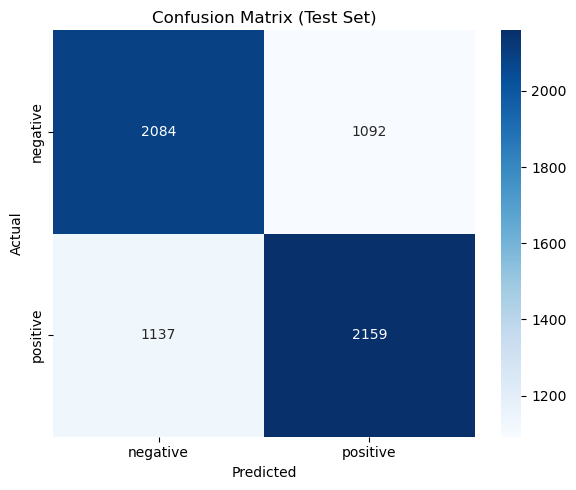

In [13]:
cm = confusion_matrix(test_y, test_preds, labels=clf.classes_)
labels = clf.classes_

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

C:\Users\robca\AppData\Local\Temp\ipykernel_21128\3994592422.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:top_n], y=np.array(feature_names)[indices][:top_n], palette='viridis')


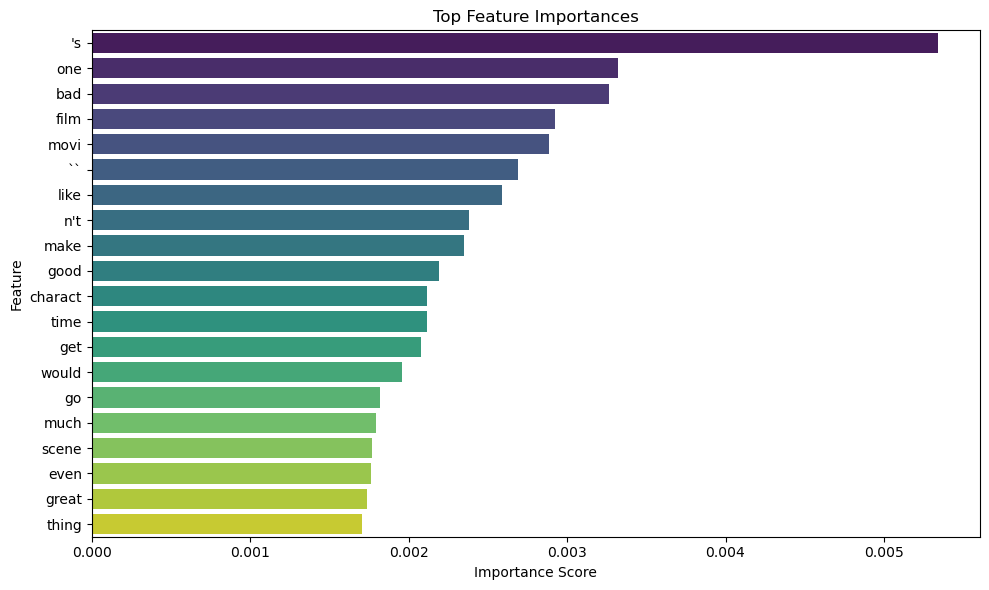

In [15]:
# Get feature names
feature_names = clf.named_steps['dictvectorizer'].get_feature_names_out()

# Get feature importances from RandomForest
importances = clf.named_steps['randomforestclassifier'].feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]
top_n = 20  # Number of top features to display

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:top_n], y=np.array(feature_names)[indices][:top_n], palette='viridis')
plt.title('Top Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [17]:

# Count occurrences of each feature in positive and negative classes
feature_class_counts = defaultdict(lambda: {'positive': 0, 'negative': 0})

# Go through training data and count
for feats, label in training_set:
    for word in feats:
        feature_class_counts[word][label] += 1

# Match with feature importance from the model
feature_names = clf.named_steps['dictvectorizer'].get_feature_names_out()
importances = clf.named_steps['randomforestclassifier'].feature_importances_
feature_importance_pairs = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

# Print top features with class bias
top_n = 20
print(f"\nTop {top_n} Most Important Features with Class Bias: ")
for i, (feature, importance) in enumerate(feature_importance_pairs[:top_n], start=1):
    pos_count = feature_class_counts[feature]['positive']
    neg_count = feature_class_counts[feature]['negative']
    total = pos_count + neg_count
    if total == 0:
        continue
    dominant_class = 'positive' if pos_count > neg_count else 'negative'
    bias_ratio = max(pos_count, neg_count) / total
    print(f"{i}. {feature}: importance={importance:.4f}, dominant_class={dominant_class}, ratio={bias_ratio:.2f}")



Top 20 Most Important Features with Class Bias: 
1. 's: importance=0.0053, dominant_class=positive, ratio=0.52
2. one: importance=0.0033, dominant_class=positive, ratio=0.52
3. bad: importance=0.0033, dominant_class=negative, ratio=0.74
4. film: importance=0.0029, dominant_class=positive, ratio=0.55
5. movi: importance=0.0029, dominant_class=negative, ratio=0.54
6. ``: importance=0.0027, dominant_class=negative, ratio=0.52
7. like: importance=0.0026, dominant_class=negative, ratio=0.52
8. n't: importance=0.0024, dominant_class=negative, ratio=0.55
9. make: importance=0.0024, dominant_class=positive, ratio=0.52
10. good: importance=0.0022, dominant_class=positive, ratio=0.51
11. charact: importance=0.0021, dominant_class=positive, ratio=0.53
12. time: importance=0.0021, dominant_class=positive, ratio=0.52
13. get: importance=0.0021, dominant_class=negative, ratio=0.53
14. would: importance=0.0020, dominant_class=negative, ratio=0.53
15. go: importance=0.0018, dominant_class=negative, r